In [81]:
import numpy as np
import xarray as xr
import os
# import fsspec
os.chdir('/meddy/simingzhang/Analysis/python/python3')
import R_tools_new_goth as tN
os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')


import matplotlib
import matplotlib.pyplot as plt
import gsw_xarray as gsw
from dask.diagnostics import ProgressBar
import pandas as pd

%matplotlib inline
plt.rcParams.update({'font.size': 13})

import importlib

import StrucFunction
importlib.reload(StrucFunction)
from StrucFunction import *
import spectralanalysis
importlib.reload(spectralanalysis)
from spectralanalysis import *
import structfunc2KEflux
importlib.reload(structfunc2KEflux)
from structfunc2KEflux import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

In [82]:
# os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:L-1]=0.5*(var_u[:,0:Lm-1]+var_u[:,1:L-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,Lp-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:M-1,:]=0.5*(var_v[0:Mm-1,:]+var_v[1:M-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[Mp-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

In [83]:
os.getcwd()

'/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS'

In [67]:
output_dir='/meddy/simingzhang/Data/HIT2D/2dt2'


grid_dir='/meddy/simingzhang/Data/HIT2D/2dt2'

# os.chdir(grid_dir)

import scipy.io as sio
from tqdm import tqdm
grid=sio.loadmat(f'{grid_dir}/HIT2D_Parameters.mat')
Diag=grid['Diag']
mm=grid['mm']
kk=grid['kk']
u=np.zeros((199,512,512))
v=np.zeros_like(u)

for i in tqdm(range(0,199)):
    fname=f'{output_dir}/HIT2D_t_{i+4000}.mat'
    data=sio.loadmat(fname)
    hq=data['hq']
    
    hpsi=Diag*hq;
    hu1=-1j*mm*hpsi;
    hw1=1j*kk*hpsi;
    u[i,:,:]=np.real(np.fft.ifft2(hu1))
    v[i,:,:]=np.real(np.fft.ifft2(hw1))

100%|██████████████████████████████████████████████████████████| 199/199 [00:05<00:00, 33.82it/s]


In [68]:
un=u
vn=v
x=(np.arange(512)+1)*2*np.pi/512
y=x
# x

In [12]:
# a1=tN.diffx_2d(u[1,:,:],np.ones(u[1,:,:].shape))
# a1.shape

In [13]:
# def shear2d_periodic(u,v,pm=1,pn=1):
    
#     ux=u2rho( diffx(u,pm))
#     vy=v2rho( diffy(v,pn))
#     uy=v2rho( diffy(u,pn))
#     vx=u2rho( diffx(v,pm))   

#     ux[0,:]=0
#     ux[-1,:]=0

#     vx[0,:]=0
#     vx[-1,:]=0

#     uy[:,0]=0
#     uy[:,-1]=0

#     vy[:,0]=0
#     vy[:,-1]=0

#     return (ux,uy,vx,vy) 

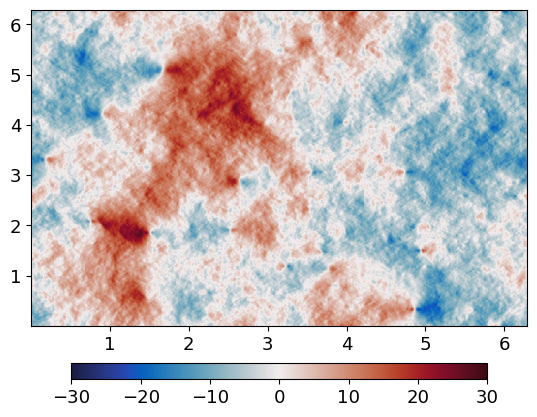

In [14]:
u1=u
from cmocean import cm
X,Y=np.meshgrid(x,y)
tin=100
cs2=plt.pcolormesh(X,Y,np.squeeze(v[tin,:,:]),cmap=cm.balance,vmin=-30,vmax=30)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

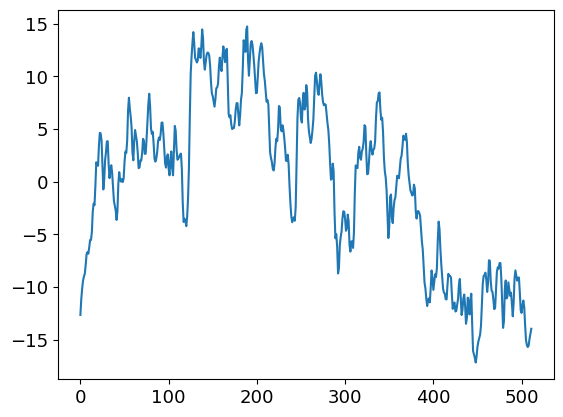

In [7]:
plt.plot(v[tin,256,:])
plt.show()

In [26]:
from scipy.signal import get_window
from scipy.fft import rfft2, irfft2
pad_ratio=1
ur=v[tin,:,:]
Ny, Nx = ur.shape
    
# 1. 计算镜像扩展尺寸
pad_x = int(Nx * pad_ratio)
pad_y = int(Ny * pad_ratio)

# 2. 镜像扩展边界
ur_padded = np.pad(ur, ((pad_y, pad_y), (pad_x, pad_x)), mode='wrap')
Ny_pad, Nx_pad = ur_padded.shape

x_padded = np.linspace(-pad_x, Nx + pad_x, Nx_pad)  # 扩展x坐标
y_padded = np.linspace(-pad_y, Ny + pad_y, Ny_pad)  # 扩展y坐标
X_padded, Y_padded = np.meshgrid(x_padded, y_padded)  # 填充后网格

# 3. 在扩展数据上创建Tukey窗 (二维)
window_x = get_window(('tukey', 0.1), Nx_pad)
window_y = get_window(('tukey', 0.1), Ny_pad)
w = np.outer(window_y, window_x)

# 4. 加窗并FFT
u11 = rfft2(ur_padded * w)
ur_filtered_padded = irfft2(u11, s=(Ny_pad, Nx_pad))
ur_filtered = ur_filtered_padded[pad_y:pad_y+Ny, pad_x:pad_x+Nx]

In [27]:
ur_padded.shape

(1536, 1536)

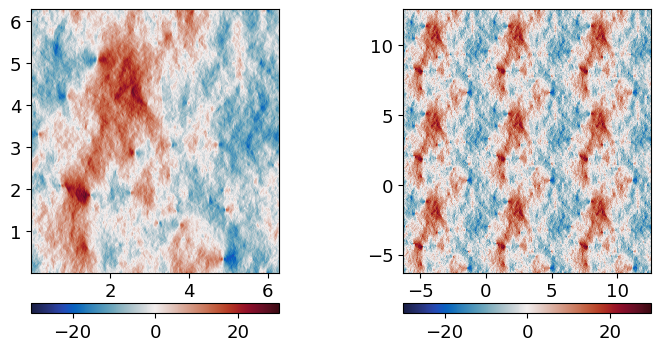

In [28]:
from matplotlib.gridspec import GridSpec

fig2 = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, figure=fig2, height_ratios=[1], wspace=0.5)
ax2 = [
    [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1])]  # First row (3 columns)
]
cs2=ax2[0][0].pcolormesh(X,Y,np.squeeze(v[tin,:,:]),cmap=cm.balance,vmin=-30,vmax=30)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

cs2=ax2[0][1].pcolormesh(X_padded*2*np.pi/512,Y_padded*2*np.pi/512,ur_padded,cmap=cm.balance,vmin=-30,vmax=30)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

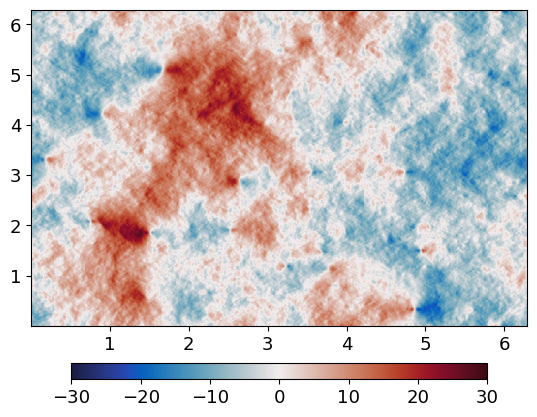

In [29]:
cs2=plt.pcolormesh(X,Y,ur_filtered,cmap=cm.balance,vmin=-30,vmax=30)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

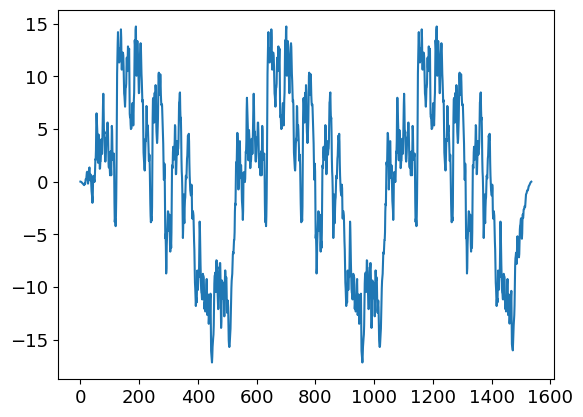

In [30]:
# plt.plot(ur_filtered[256,:])
plt.plot(ur_filtered_padded[256,:])

plt.show()

In [84]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

wind = 0  # no windowing
detr = 0  # no detrend

# Assuming eddyrun_lev is a preloaded xarray dataset
# un = u1.chunk({'time': 100, 'x': 256, 'y': 256})
# vn = v1.chunk({'time': 100, 'x': 256, 'y': 256})

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])

# flux = np.zeros((Nt, Nk))

# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

  0%|          | 0/199 [00:00<?, ?it/s]

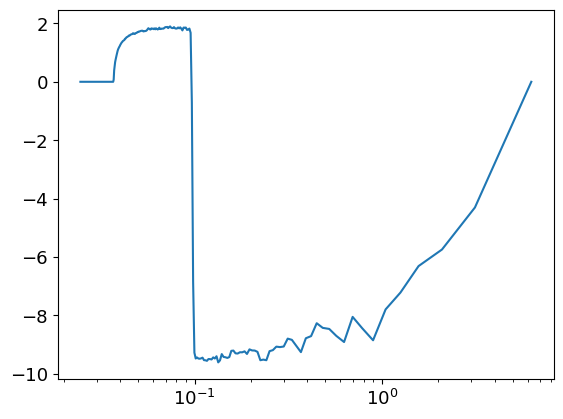

In [85]:
plt.semilogx(1/K1D,specFlux_mean)
plt.show()

In [87]:
sio.savemat('HIT2d_fftfk.mat',{'K1D':K1D,'specFlux_mean':specFlux_mean,'specFlux_std':specFlux_std,
                               'divFlux_mean':divFlux_mean,'divFlux_std':divFlux_std})

# transform drifts

In [4]:
import scipy.io
import pickle

mat_data = scipy.io.loadmat('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/traj_mat_GLAD_15min_04_May_2021.mat')
print(mat_data.keys()) 
with open('traj_mat_GLAD_15min_04_May_2021.pkl', 'wb') as f:
    pickle.dump(mat_data, f)

mat_data = scipy.io.loadmat('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/traj_mat_LASER_15min_04_May_2021.mat')
print(mat_data.keys()) 
with open('traj_mat_LASER_15min_04_May_2021.pkl', 'wb') as f:
    pickle.dump(mat_data, f)

dict_keys(['__header__', '__version__', '__globals__', 'T_axis', 'trajmat_U', 'trajmat_V', 'trajmat_X', 'trajmat_Y'])
dict_keys(['__header__', '__version__', '__globals__', 'T_axis', 'trajmat_U', 'trajmat_V', 'trajmat_X', 'trajmat_Y'])


In [6]:
import mat73
import pickle

# 文件路径
file_path = '/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/pairs_sep_GLAD.mat'

# 加载 MATLAB v7.3 文件
data = mat73.loadmat(file_path)

# 打印所有键（变量名）
print("文件中的变量:", list(data.keys()))

# 保存为 PKL 文件
with open('pairs_sep_GLAD.pkl', 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("文件已成功保存为 pairs_sep_GLAD.pkl")

文件中的变量: ['dist_axis', 'pairs_sep']
文件已成功保存为 pairs_sep_GLAD.pkl


In [7]:
import mat73
import pickle

# 文件路径
file_path = '/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/pairs_sep_LASER.mat'

# 加载 MATLAB v7.3 文件
data = mat73.loadmat(file_path)

# 打印所有键（变量名）
print("文件中的变量:", list(data.keys()))

# 保存为 PKL 文件
with open('pairs_sep_LASER.pkl', 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("文件已成功保存为 pairs_sep_LASER.pkl")

文件中的变量: ['dist_axis', 'pairs_sep']
文件已成功保存为 pairs_sep_LASER.pkl


# calc fft-specflux Iceland

In [64]:
outpur_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_wave'


grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'

os.chdir(grid_dir)
grid=xr.open_dataset('niskin2km_500m_grd.nc')

os.chdir(outpur_dir)
dataw=xr.open_dataset('z_niskin2km_his_hf_depth_500m_grd.0002.nc')

dsw = xr.merge([dataw,grid])
print(dsw)
print('\n data size: %.1f GB' %(dsw.nbytes / 1e9))

# nowave
outpur_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave'

grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'

os.chdir(grid_dir)
grid=xr.open_dataset('niskin2km_500m_grd.nc')

os.chdir(outpur_dir)
datanw=xr.open_dataset('z_niskin2km_his_smooth_depth_500m_grd.0002.nc')
dsnw = xr.merge([datanw,grid])
print(dsnw)
print('\n data size: %.1f GB' %(dsnw.nbytes / 1e9))


os.chdir('/meddy/simingzhang/Data/RB_iceland_data/')

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287, one: 1, bath: 1, eta_u: 287, xi_v: 287,
                 eta_psi: 286, xi_psi: 286)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho, one, bath,
                                eta_u, xi_v, eta_psi, xi_psi
Data variables: (12/38)
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    xl          (one) float64 8B ...
    el          (one) float64 8B ...
    ...          ...
    lat_v       (eta_v, xi_v) float64 657kB ...
    lat_psi     (eta_psi, xi_psi) float64 654kB ...
    mask_rho    (eta_rho, xi_rho) float64 659kB ...
    mask_u      (eta_u, xi_u) float64 657kB ...
    mask_v      (eta_v, xi_v) float64 657

In [65]:
dsw

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287, one: 1, bath: 1, eta_u: 287, xi_v: 287,
                 eta_psi: 286, xi_psi: 286)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho, one, bath,
                                eta_u, xi_v, eta_psi, xi_psi
Data variables: (12/38)
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    xl          (one) float64 8B ...
    el          (one) float64 8B ...
    ...          ...
    lat_v       (eta_v, xi_v) float64 657kB ...
    lat_psi     (eta_psi, xi_psi) float64 654kB ...
    mask_rho    (eta_rho, xi_rho) float64 659kB ...
    mask_u      (eta_u, xi_u) float64 657kB ...
    mask_v      (eta_v, xi_v) float64 657kB ...
    mask_psi    (eta_psi, xi_psi) float64 654kB ...
Attributes:
    history:                   Thu Jul 18 14:58:06 2019: ncrcat -d depth,0 z_...
    nco_openmp_thread_number:  1

In [86]:
Case='nowave'
if Case=='wave':
    un=u2rho_3d(np.squeeze(dsw['u'].values))
    vn=v2rho_3d(np.squeeze(dsw['v'].values))
if Case=='nowave':
    un=u2rho_3d(np.squeeze(dsnw['u'].values))
    vn=v2rho_3d(np.squeeze(dsnw['v'].values))
xs=np.mean([1/grid['pm'].values,1/grid['pn'].values])

x=(np.arange(287)+1)*xs
y=x

In [87]:
un.shape

(2148, 287, 287)

In [88]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

wind = 1  # no windowing
detr = 0  # no detrend

# Assuming eddyrun_lev is a preloaded xarray dataset
# un = u1.chunk({'time': 100, 'x': 256, 'y': 256})
# vn = v1.chunk({'time': 100, 'x': 256, 'y': 256})

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])

# flux = np.zeros((Nt, Nk))

# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

  0%|          | 0/2148 [00:00<?, ?it/s]

In [89]:
import scipy.io as sio
sio.savemat(f'{Case}_fftspec.mat',{'K1D':K1D,'specFlux_mean':specFlux_mean,'specFlux_std':specFlux_std,
                               'divFlux_mean':divFlux_mean,'divFlux_std':divFlux_std})
Case

'nowave'

In [90]:
os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')

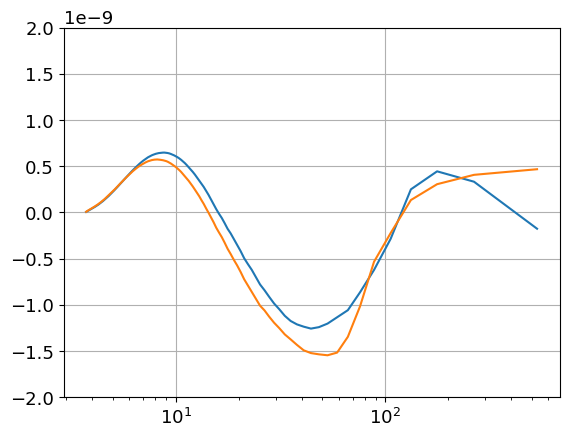

In [92]:
data=sio.loadmat('wave_fftspec.mat')
specFlux_mean=data['specFlux_mean'][0,:]
K1D=data['K1D'][0,:]
plt.semilogx(1/K1D/1e3,specFlux_mean)
data=sio.loadmat('nowave_fftspec.mat')
specFlux_mean=data['specFlux_mean'][0,:]
plt.semilogx(1/K1D/1e3,specFlux_mean)
plt.ylim([-2e-9,2e-9])
plt.grid(True)
plt.show()

# check cg using xscale
### spatial_cg_RB

# check cg_sfilt_mirror

In [92]:
# s2sflux_spec_all_hf.0002.nc
input_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='s2sflux_spec.0002.nc'
ds=xr.open_dataset(f'{input_dir}{fname}')
filtscale=ds['filtscale']
Thm=ds['Thm']

In [93]:
Ekm=ds['Ekm'].values

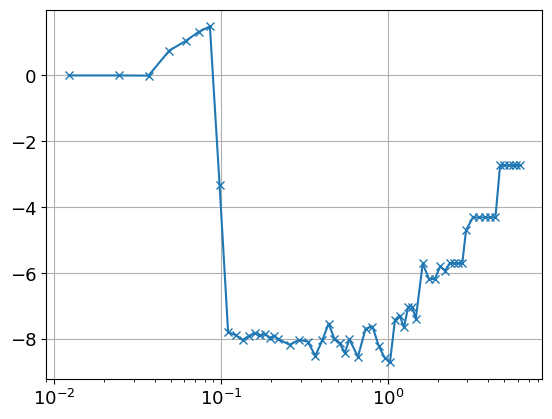

In [94]:
plt.semilogx(filtscale,Thm,marker='x')
plt.grid(True)
# plt.ylim([25e-8,2e-8])

plt.show()

In [91]:
Thm

<xarray.DataArray 'Thm' (filtscale: 17)> Size: 68B
array([-1.036722e-06,  1.657768e-04, -5.183336e-03,  7.568321e-01,
        1.043871e+00,  1.322669e+00,  1.489348e+00, -3.324704e+00,
       -7.791777e+00, -7.883991e+00, -8.030340e+00, -7.901367e+00,
       -7.827014e+00, -7.890855e+00, -7.853323e+00, -7.962021e+00,
       -7.907183e+00], dtype=float32)
Coordinates:
  * filtscale  (filtscale) float32 68B 0.01227 0.02454 0.03682 ... 0.1964 0.2086

In [40]:
# fname='s2sflux_spec_all_hf.0002.nc'
fname='s2sflux_spec_all_hit.0002.nc'

ds=xr.open_dataset(f'{input_dir}{fname}')
Th2=np.squeeze(ds['Th2'].values[100,:,:,:])
# lonr=grid['lon_rho'].values
# latr=grid['lat_rho'].values

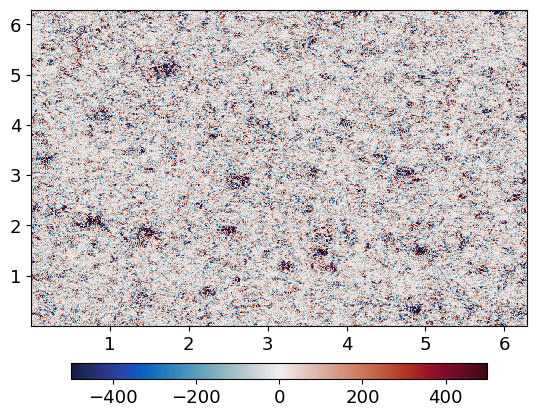

In [41]:
from cmocean import cm
# plt.pcolormesh(X,Y,Th2,cmap=cm.balance,vmin=-5e-7,vmax=5e-7)
cs2=plt.pcolormesh(X,Y,Th2,cmap=cm.balance,vmin=-500,vmax=500)
colorbar2=plt.colorbar(cs2, orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

plt.show()

In [42]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 199, depth: 1, eta_rho: 512, xi_rho: 512)
Dimensions without coordinates: time, depth, eta_rho, xi_rho
Data variables: (12/17)
    Th1      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th2      (time, depth, eta_rho, xi_rho) float32 209MB -63.4 -83.8 ... -141.7
    Th3      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th4      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th5      (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th6      (time, depth, eta_rho, xi_rho) float32 209MB ...
    ...       ...
    Th12     (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th13     (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th14     (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th15     (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th16     (time, depth, eta_rho, xi_rho) float32 209MB ...
    Th17     (time, depth, eta_rho, xi_rho) float32 209MB ...

In [43]:
Narray = list(range(1,18))
# Narray.extend(list(range(18,int(48),int(3))))
# Narray.extend(list(range(48,int(120),int(6))))
# Narray.extend(list(range(120,int(240),int(12))))
# Narray.extend(list(range(240,int(520),int(24))))
Thm=np.zeros((199,len(Narray)))
for ii in range(len(Narray)):
    var=f'Th{Narray[ii]}'
    print(var)
    Thm[:,ii]=np.squeeze(np.nanmean(ds[var].values[:,:,230:-230,230:-230],axis=(2,3)))

Th1
Th2
Th3
Th4
Th5
Th6
Th7
Th8
Th9
Th10
Th11
Th12
Th13
Th14
Th15
Th16
Th17


In [48]:
Thm_std=np.std(Thm,axis=0)

In [44]:
# np.nanmean(ds[var].values,axis=(2,3))
np.nanmean(Thm,axis=0)

array([-3.73781383e-03,  9.14388938e-01,  1.19073163e+00, -7.20742910e+00,
       -7.95164613e+00, -9.85274167e+00, -8.50069481e+00, -7.08158390e+00,
       -7.55285332e+00, -6.79806632e+00, -7.51768548e+00, -9.41482152e+00,
       -7.43613864e+00, -6.31114436e+00, -5.72956973e+00, -5.41426731e+00,
       -3.58808424e+00])

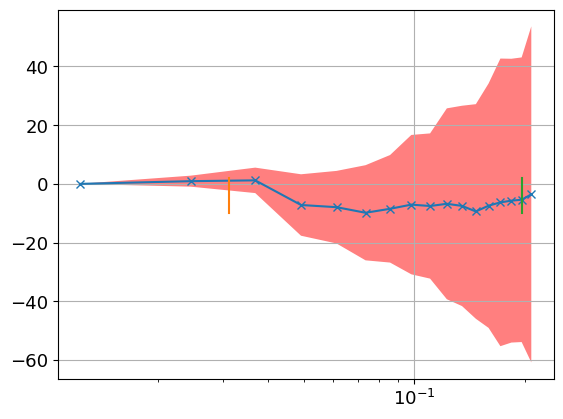

In [50]:
# for ii in range(Thm.shape[0]):
    # plt.semilogx(filtscale,Thm[ii,:],marker='x')
plt.semilogx(filtscale,np.nanmean(Thm,axis=0),marker='x')
plt.fill_between(filtscale,np.nanmean(Thm,axis=0)+Thm_std, 
                       np.nanmean(Thm,axis=0)-Thm_std, 
                       facecolor='r', edgecolor=None, alpha=0.5)
plt.plot([1/32,1/32],[-10,2])
plt.plot([2*np.pi*1/32,2*np.pi*1/32],[-10,2])

plt.grid(True)
# plt.ylim([25e-8,2e-8])
# plt.ylim([-10,2])

plt.show()

In [288]:
from scipy.signal import get_window
window_x = get_window(('kaiser', 14), 10)
window_y = np.ones((10))
window_x = np.ones((10))

window_y.shape

(10,)

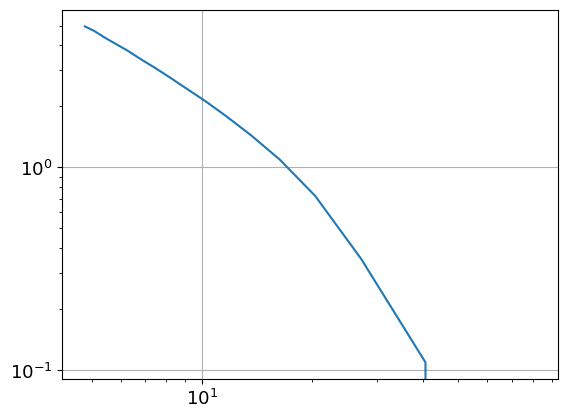

In [39]:
plt.loglog(1/filtscale,Ekm)
plt.grid(True)
plt.show()

# check HIT2d_new.0002.nc

In [27]:
input_dir='/meddy/simingzhang/Data/RB_iceland_data/'
hname='HIT2d_new.0002.nc'
ds=xr.open_dataset(f'{input_dir}{hname}')

In [32]:
np.min(ds['pm'].values),np.min(ds['pn'].values),np.max(ds['pm'].values),np.max(ds['pn'].values)

(81.48714031066973, 81.48714031066973, 81.48714031066973, 81.48714031066973)

In [77]:
dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK = max(ddk, ddl)
K1D = dK*np.arange(1, int(Kmax/dK)+3)

In [86]:
(1/np.array(K1D)).shape


(256,)

In [61]:
np.arange(1, int(Kmax/dK))

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [64]:
dK

0.15915494309189532

In [66]:
1/512/2/np.pi

0.0003108494982263581